# Tutorial 03 — Trích Đặc Trưng & Khám Phá Dữ Liệu (EDA)

> **Mục tiêu:** Biến tín hiệu rung (hàng trăm nghìn số) thành **bảng đặc trưng gọn** mà SVM / Random Forest có thể học được, và **nhìn** xem đặc trưng nào phân biệt được loại lỗi.

---

## 🎯 Vì sao cần trích đặc trưng?

Một segment 2048 mẫu = **2048 chiều** — quá nhiều, nhiễu, và máy học sẽ "lạc". Giải pháp: nén mỗi segment thành **19 con số có ý nghĩa vật lý** (RMS, kurtosis, năng lượng dải tần…). Mỗi con số là một "góc nhìn" về tín hiệu.

| Bước | Đầu vào | Đầu ra |
|---|---|---|
| ① Cắt segment | Tín hiệu dài ~244k mẫu | Nhiều đoạn 2048 mẫu (overlap 50%) |
| ② Trích đặc trưng | 1 segment (2048 số) | 1 vector **19 đặc trưng** |
| ③ Gán nhãn + group | Tên file | Nhãn (Normal/IR/OR/B) + `file_id` |
| ④ Lưu CSV | Toàn bộ | `X_features.csv`, `y_labels.csv`, `groups.csv` |

> 📌 **Điểm mới quan trọng:** Ta ghi thêm `file_id` cho mỗi segment. Vì các segment **chồng lấp 50%** nên nếu sau này chia train/test ngẫu nhiên sẽ bị **rò rỉ dữ liệu**. `file_id` cho phép Tutorial 04/05 chia tập **theo file** — đánh giá trung thực.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sp_stats
from scipy.fft import fft, fftfreq
import os, glob

DATA_ROOT = "./data"
SAMPLE_RATE = 12000
WINDOW_SIZE = 2048
OVERLAP = 0.5

plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100, 'font.size': 12})
sns.set_style("whitegrid")
print("OK!")


OK!


## 1. Cắt segment (Windowing)

Tín hiệu dài hàng trăm nghìn mẫu → cắt thành nhiều đoạn ngắn **2048 mẫu (~0.17 s ở 12 kHz)**, trượt với **overlap 50%**.

| Khái niệm | Giá trị | Lý do |
|---|---|---|
| **Window size** | 2048 mẫu | Chứa ~5 vòng quay trục → đủ thấy mẫu lặp đặc trưng lỗi |
| **Overlap** | 50% (bước 1024) | Tăng số mẫu huấn luyện, không bỏ sót xung ở biên cửa sổ |

> ⚠️ **Hệ quả của overlap (phải nhớ):** Hai segment kề nhau **dùng chung 1024 mẫu** → chúng gần như trùng nhau. Nếu chia train/test ngẫu nhiên, một segment vào train còn "bản sao" của nó vào test ⇒ mô hình **học thuộc đề** ⇒ accuracy ảo cao. Đó là lý do ta gắn `file_id` ở mục 3 và chia theo file ở Tutorial 04.


In [2]:
def segment_signal(signal, window_size=WINDOW_SIZE, overlap=OVERLAP):
    """Cắt tín hiệu thành các đoạn ngắn bằng cửa sổ trượt."""
    step = int(window_size * (1 - overlap))
    n_seg = (len(signal) - window_size) // step + 1
    return np.array([signal[i*step : i*step+window_size] for i in range(n_seg)])

# Demo
sig = np.load(os.path.join(DATA_ROOT, "0HP", "Normal_DE.npy"))
segs = segment_signal(sig)
print(f"Tín hiệu gốc: {len(sig)} mẫu")
print(f"Sau cắt: {segs.shape[0]} segments x {segs.shape[1]} mẫu/segment")
print(f"Overlap: {OVERLAP*100:.0f}%  →  Step: {int(WINDOW_SIZE*(1-OVERLAP))} mẫu")


Tín hiệu gốc: 243938 mẫu
Sau cắt: 237 segments x 2048 mẫu/segment
Overlap: 50%  →  Step: 1024 mẫu


## 2. Trích đặc trưng — 19 con số / segment

Chia làm **3 nhóm góc nhìn**:

### 🕒 Nhóm A — Miền thời gian (11 đặc trưng): "rung mạnh & nhọn cỡ nào?"

| Đặc trưng | Ý nghĩa | Nhạy với |
|---|---|---|
| `mean`, `std` | Trung bình & độ phân tán | Mức rung tổng thể |
| `rms` | Năng lượng rung hiệu dụng | Hư hỏng đã phát triển |
| `peak`, `p2p` | Đỉnh & biên độ đỉnh-đỉnh | Xung va chạm mạnh |
| `skewness` | Độ lệch phân bố | Bất đối xứng bất thường |
| **`kurtosis`** | **Độ nhọn — "chuông báo sớm"** | Xung va chạm (rất nhạy) |
| `crest_factor` = peak/rms | Xung nhọn so với nền | Lỗi giai đoạn đầu |
| `shape_factor`, `impulse_factor`, `clearance_factor` | Các tỉ số dạng sóng | Đặc tính xung |

> ⚠️ **Kurtosis dùng `fisher=False` (Pearson):** Gaussian = **3** (không phải 0). Đây là quy ước ngành chẩn đoán rung và **khớp với tài liệu PhanA/PhanD**. Mặc định `scipy.stats.kurtosis()` là Fisher (excess, Gaussian=0) — ta đã sửa lại. Ngưỡng: **>3.5** theo dõi, **>6** lên kế hoạch, **>10** hành động.

### 📊 Nhóm B — Miền tần số (5 đặc trưng): "phổ phân bố ra sao?"
`fft_energy`, `fft_mean`, `fft_std`, `fft_skewness`, `fft_kurtosis` — mô tả hình dạng phổ FFT.

### 🎚️ Nhóm C — Năng lượng theo dải tần (3 đặc trưng): "năng lượng nằm ở dải nào?"
`energy_0_500Hz`, `energy_500_2000Hz`, `energy_2000_6000Hz`.

> 💡 **Lưu ý vật lý:** Các tần số lỗi cơ bản **BPFO≈107, BPFI≈162 Hz, và lỗi bi ≈ 2·BSF ≈ 141 Hz** (BSF tự quay cơ bản ≈ 70.6 Hz) đều nằm trong dải `0_500Hz`. Dải này gộp chung nên *không tách được loại lỗi* chỉ bằng 1 con số — nhưng kết hợp với xung (kurtosis, crest) và năng lượng cộng hưởng (`2000_6000Hz`), mô hình ML vẫn phân loại tốt. (Tách riêng từng tần số lỗi cần *envelope analysis* — xem PhanA.)


In [3]:
def extract_features(segment, fs=SAMPLE_RATE):
    """Trích 19 đặc trưng từ 1 segment."""
    f = {}
    # Miền thời gian
    f['mean'] = np.mean(segment)
    f['std'] = np.std(segment)
    f['rms'] = np.sqrt(np.mean(segment**2))
    f['peak'] = np.max(np.abs(segment))
    f['p2p'] = np.max(segment) - np.min(segment)
    f['skewness'] = sp_stats.skew(segment)
    # fisher=False -> Pearson kurtosis: Gaussian = 3 (chuẩn ngành rung, khớp tài liệu)
    # (mặc định scipy là fisher=True -> excess kurtosis, Gaussian = 0)
    f['kurtosis'] = sp_stats.kurtosis(segment, fisher=False)
    rms = f['rms']
    mean_abs = np.mean(np.abs(segment))
    f['crest_factor'] = f['peak'] / rms if rms > 0 else 0
    f['shape_factor'] = rms / mean_abs if mean_abs > 0 else 0
    f['impulse_factor'] = f['peak'] / mean_abs if mean_abs > 0 else 0
    sqrt_mean = np.mean(np.sqrt(np.abs(segment)))**2
    f['clearance_factor'] = f['peak'] / sqrt_mean if sqrt_mean > 0 else 0
    
    # Miền tần số
    n = len(segment)
    yf = np.abs(fft(segment)[:n//2])
    freqs = fftfreq(n, 1/fs)[:n//2]
    f['fft_energy'] = np.sum(yf**2) / n
    f['fft_mean'] = np.mean(yf)
    f['fft_std'] = np.std(yf)
    f['fft_skewness'] = sp_stats.skew(yf)
    f['fft_kurtosis'] = sp_stats.kurtosis(yf, fisher=False)  # Pearson, đồng nhất với trên
    
    for lo, hi, name in [(0,500,'0_500Hz'), (500,2000,'500_2000Hz'), (2000,6000,'2000_6000Hz')]:
        mask = (freqs >= lo) & (freqs < hi)
        f[f'energy_{name}'] = np.sum(yf[mask]**2) / n if mask.any() else 0
    return f

# Test
feat = extract_features(segs[0])
print(f"Mỗi segment -> {len(feat)} đặc trưng")
print(f"Kurtosis (Pearson) của segment Normal đầu tiên ≈ {feat['kurtosis']:.2f}  (kỳ vọng ~3 vì Normal gần Gaussian)")


Mỗi segment -> 19 đặc trưng
Kurtosis (Pearson) của segment Normal đầu tiên ≈ 2.95  (kỳ vọng ~3 vì Normal gần Gaussian)


## 3. Xây dựng dataset hoàn chỉnh

Duyệt mọi file `.npy` (4 mức tải 0–3 HP) → cắt segment → trích đặc trưng → gán **nhãn** + **`file_id`**.

> 🔑 **`file_id`** = `"<tải>/<tên_file>"` (vd `0HP/IR_007_DE.npy`). Mọi segment cắt ra từ cùng một file mang **cùng** `file_id`. Đây chính là "nhóm" (group) để Tutorial 04/05 chia train/test sao cho **không file nào nằm cả ở train lẫn test**.

> ⚠️ **Lưu ý mất cân bằng lớp:** Số file OR nhiều hơn hẳn (3/6/12 giờ × nhiều kích thước) nên OR sẽ có nhiều segment nhất, Normal ít nhất. Ghi nhớ điều này khi đọc accuracy ở Tutorial 04 (nên xem thêm precision/recall từng lớp, không chỉ accuracy tổng).


In [4]:
def parse_label(filename):
    base = filename.replace('_DE.npy','').lower()
    if 'normal' in base: return 'Normal'
    elif base.startswith('ir'): return 'IR'
    elif base.startswith('or'): return 'OR'
    elif base.startswith('b'): return 'B'
    return None

rows, labels, groups = [], [], []
domains = ['0HP','1HP','2HP','3HP']

for domain in domains:
    dpath = os.path.join(DATA_ROOT, domain)
    if not os.path.isdir(dpath): continue
    for fp in sorted(glob.glob(os.path.join(dpath, "*.npy"))):
        label = parse_label(os.path.basename(fp))
        if label is None: continue
        # file_id = định danh DUY NHẤT cho mỗi file nguồn (vd '0HP/IR_007_DE.npy')
        # -> tất cả segment cắt từ cùng 1 file mang cùng file_id.
        file_id = f"{domain}/{os.path.basename(fp)}"
        sig = np.load(fp)
        segs = segment_signal(sig)
        for s in segs:
            rows.append(extract_features(s))
            labels.append(label)
            groups.append(file_id)
    print(f"{domain}: done")

X_features = pd.DataFrame(rows)
y_labels = pd.Series(labels, name='fault_type')
file_ids = pd.Series(groups, name='file_id')   # dùng cho GroupShuffleSplit ở Tutorial 04/05
print(f"\nDataset: {X_features.shape[0]} mau x {X_features.shape[1]} features")
print(f"So file nguon (group): {file_ids.nunique()}")
print(y_labels.value_counts())


0HP: done


1HP: done


2HP: done


3HP: done

Dataset: 22594 mau x 19 features
So file nguon (group): 56
fault_type
OR        10679
B          5458
IR         4805
Normal     1652
Name: count, dtype: int64


## 4. EDA — So sánh đặc trưng giữa các lớp lỗi (Boxplot)

Boxplot cho thấy **phân bố** mỗi đặc trưng theo từng loại lỗi.

**Cách đọc boxplot:**
- **Hộp** = khoảng 50% dữ liệu giữa (Q1→Q3); **vạch giữa** = trung vị.
- **Râu** = phạm vi điển hình; điểm ngoài = ngoại lệ (ở đây ẩn `showfliers=False` cho gọn).

| Quan sát | Diễn giải cho kỹ sư |
|---|---|
| Hộp các lớp **tách rời** nhau | Đặc trưng đó **phân biệt tốt** → ML dễ học |
| Hộp **chồng lấp** nhiều (vd Normal vs Ball) | Khó phân biệt → đây là cặp lớp dễ nhầm |
| Hộp lớp lỗi **dịch lên cao** so với Normal | Đặc trưng tăng khi có lỗi (rms, kurtosis…) |

> 💡 Hãy chú ý: `kurtosis` và `crest_factor` thường tách Normal khỏi lỗi rất sớm; còn `rms`/`peak` tách rõ khi lỗi đã nặng. **Ball** thường chồng lấp Normal nhiều nhất — đúng như dự đoán vật lý ở Tutorial 01.


C:\Users\Admin\AppData\Local\Temp\ipykernel_8436\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,


C:\Users\Admin\AppData\Local\Temp\ipykernel_8436\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_8436\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,


C:\Users\Admin\AppData\Local\Temp\ipykernel_8436\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_8436\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,


C:\Users\Admin\AppData\Local\Temp\ipykernel_8436\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,


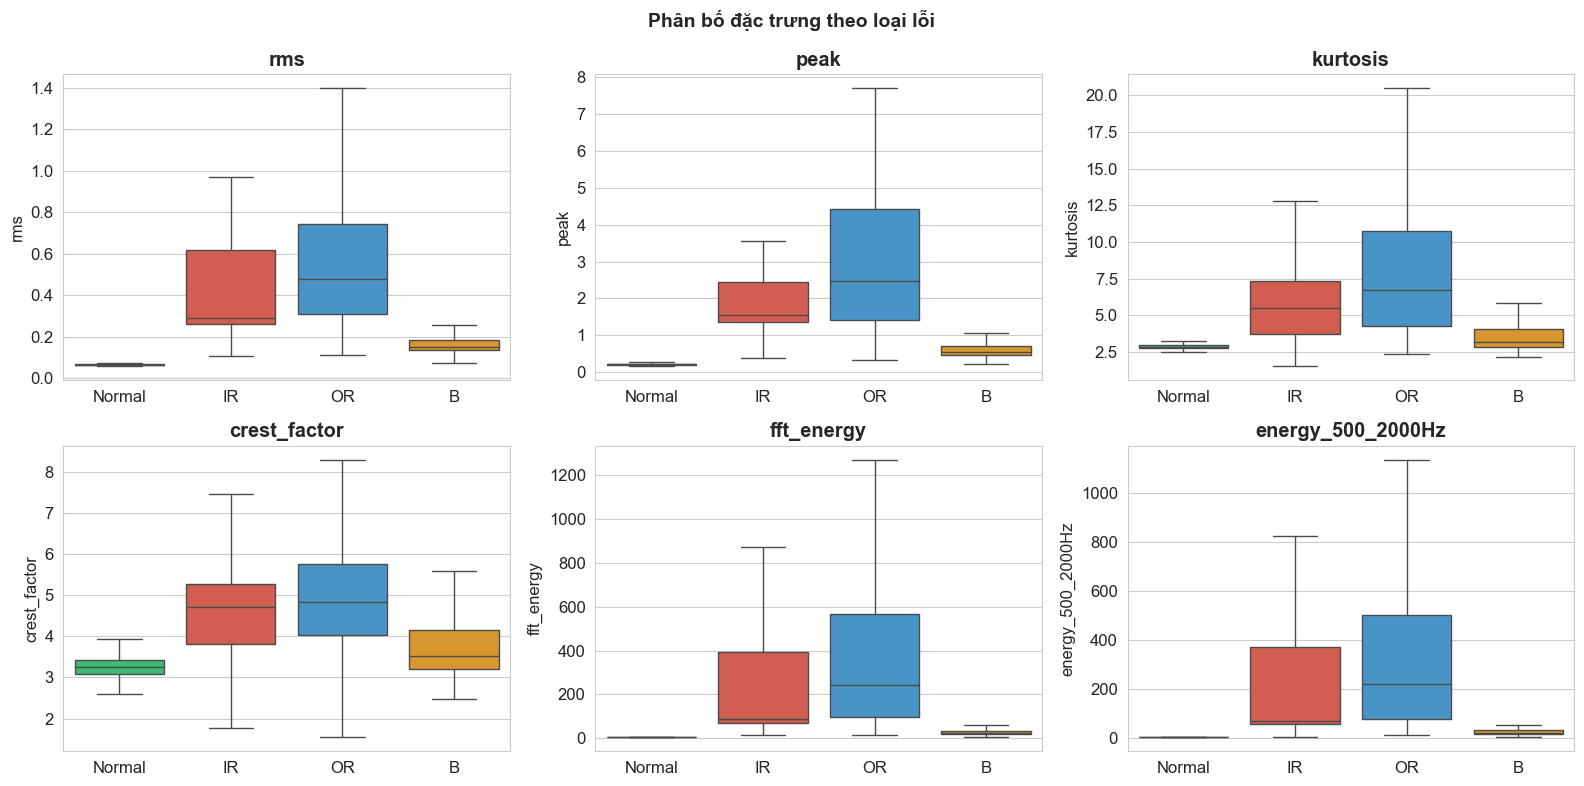

Nhận xét:
- RMS, Peak, FFT Energy: tăng rõ khi có lỗi IR/OR
- Kurtosis: rất nhạy với xung → 'chuông báo động sớm'
- Ball fault (B): khó phân biệt nhất với Normal


In [5]:
key_feats = ['rms', 'peak', 'kurtosis', 'crest_factor', 'fft_energy', 'energy_500_2000Hz']
plot_df = X_features[key_feats].copy()
plot_df['label'] = y_labels.values

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, feat in enumerate(key_feats):
    ax = axes[i//3, i%3]
    sns.boxplot(data=plot_df, x='label', y=feat, ax=ax, 
                order=['Normal','IR','OR','B'], showfliers=False,
                palette={'Normal':'#2ecc71','IR':'#e74c3c','OR':'#3498db','B':'#f39c12'})
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Phân bố đặc trưng theo loại lỗi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("- RMS, Peak, FFT Energy: tăng rõ khi có lỗi IR/OR")
print("- Kurtosis: rất nhạy với xung → 'chuông báo động sớm'")
print("- Ball fault (B): khó phân biệt nhất với Normal")


## 5. Lưu dataset để dùng cho các Tutorial sau

Lưu **3 file** để Tutorial 04/05 nạp lại nhanh (khỏi trích đặc trưng lại):

| File | Nội dung | Dùng để |
|---|---|---|
| `X_features.csv` | 19 đặc trưng × N segment | Đầu vào mô hình |
| `y_labels.csv` | Nhãn Normal/IR/OR/B | Đầu ra mô hình |
| `groups.csv` | `file_id` mỗi segment | **Chia tập theo file** (chống rò rỉ) |

> ⚠️ **Nhớ chạy lại notebook này** mỗi khi đổi `WINDOW_SIZE`/đặc trưng — vì 3 file CSV phải đồng bộ với nhau (cùng số dòng, cùng thứ tự).


In [6]:
# Lưu để các tutorial sau dùng lại (không cần trích đặc trưng lại)
X_features.to_csv("X_features.csv", index=False)
y_labels.to_csv("y_labels.csv", index=False)
file_ids.to_csv("groups.csv", index=False)   # định danh file nguồn -> chia tập theo file
print(f"Da luu: X_features.csv {X_features.shape}, y_labels.csv ({len(y_labels)}), "
      f"groups.csv ({file_ids.nunique()} file)")


Da luu: X_features.csv (22594, 19), y_labels.csv (22594), groups.csv (56 file)


## 📝 Tóm tắt & Key Takeaways

✅ **Bạn đã học:**
1. Nén segment 2048-chiều → **19 đặc trưng** có ý nghĩa vật lý (3 nhóm: thời gian / tần số / dải tần).
2. **Kurtosis dùng Pearson (`fisher=False`)** → Normal ≈ 3, đồng nhất code ↔ tài liệu.
3. Gắn **`file_id`** cho mỗi segment → nền tảng chia tập theo file (chống rò rỉ dữ liệu).
4. Boxplot: đặc trưng nào **tách lớp** thì ML học tốt; Ball–Normal chồng lấp → dễ nhầm.

🎯 **Thông điệp:** Đặc trưng tốt > thuật toán phức tạp. Kurtosis/crest là "chuông báo sớm"; năng lượng dải tần định hướng loại lỗi.

---

## 🏋️ Bài tập

1. Đổi `WINDOW_SIZE = 4096` → số segment đổi thế nào? Chạy lại cả chuỗi 03→04 xem accuracy khác ra sao.
2. Bỏ hết đặc trưng miền tần số, chỉ giữ miền thời gian → boxplot còn tách lớp đủ không?
3. Thêm đặc trưng **spectral entropy** (độ "hỗn loạn" của phổ) → nó giúp tách lớp nào?

---
*Tutorial 03/05 — Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
